<a href="https://colab.research.google.com/github/YesterKing/SCAI/blob/main/Workshop_Ray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

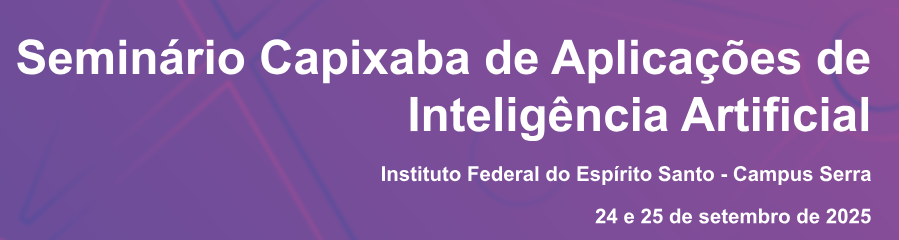

# Escalando IA com Ray.io

Todos os exemplos poderão ser realizados SEM cloud.

## 1. Instalando e configurando

In [ ]:
!pip install ray[default] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 36.7 MB/s eta 0:00:00


In [ ]:
import ray
ray.shutdown()
ray.init()

2025-09-25 19:23:10,521	INFO worker.py:1942 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Python version:,3.12.11
Ray version:,2.49.2
Dashboard:,http://127.0.0.1:8265


#### 1.1 Visualizando recursos

In [ ]:
ray.nodes()

[{'NodeID': 'f1f0d74aa2dbbc2b85ef535a6ffac61644168d3b99d6975e9f33bbd6',
  'Alive': True,
  'NodeManagerAddress': '172.28.0.12',
  'NodeManagerHostname': 'd898ef31f232',
  'NodeManagerPort': 35875,
  'ObjectManagerPort': 35887,
  'ObjectStoreSocketName': '/tmp/ray/session_2025-09-25_19-22-48_949442_249/sockets/plasma_store',
  'RayletSocketName': '/tmp/ray/session_2025-09-25_19-22-48_949442_249/sockets/raylet',
  'MetricsExportPort': 54765,
  'NodeName': '172.28.0.12',
  'RuntimeEnvAgentPort': 45720,
  'DeathReason': 0,
  'DeathReasonMessage': '',
  'alive': True,
  'Resources': {'memory': 9291723572.0,
   'object_store_memory': 3982167244.0,
   'node:__internal_head__': 1.0,
   'GPU': 1.0,
   'node:172.28.0.12': 1.0,
   'CPU': 2.0,
   'accelerator_type:T4': 1.0},
  'Labels': {'ray.io/accelerator-type': 'T4',
   'ray.io/node-id': 'f1f0d74aa2dbbc2b85ef535a6ffac61644168d3b99d6975e9f33bbd6'}}]

### 2. Nossa primeira Task: otimizando uma função

![img](https://mdrk.io/content/images/2022/03/x2_derivative_compression.gif)

##### a) Implementar função objetivo e derivada

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Função objetivo (custo)
def funcao_objetivo(x):
    return x**2

# Gradiente da função
def gradiente(x):
    return 2 * x

##### b) Otimizar por Gradiente Descendente

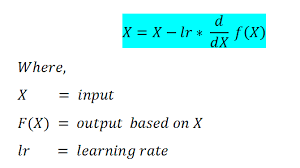

In [ ]:
@ray.remote
def otimizar_ponto(x_inicial, taxa_aprendizado=0.1, passos=20):
    x = x_inicial
    trajetoria = [x]
    for _ in range(passos):
        x = x - taxa_aprendizado * gradiente(x)
        trajetoria.append(x)
    return trajetoria


##### c) Execução

In [ ]:
X_iniciais = np.random.uniform(-10, 10, size=10_000)

# Aciona como task Ray
tarefas = [otimizar_ponto.remote(x, taxa_aprendizado=0.1, passos=20) for x in X_iniciais]
trajetorias = ray.get(tarefas)

##### d) Exibindo o resultado

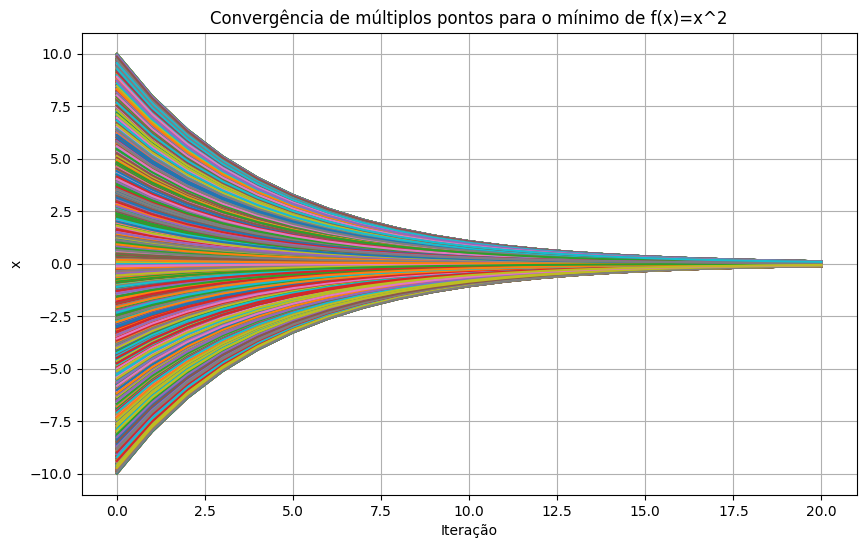

In [ ]:
# Plotando trajetórias
plt.figure(figsize=(10,6))
for i, traj in enumerate(trajetorias):
    plt.plot(traj, label=f'Ponto {i}')
plt.xlabel('Iteração')
plt.ylabel('x')
plt.title('Convergência de múltiplos pontos para o mínimo de f(x)=x^2')
plt.grid(True)
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Animação do gradient descent ---
fig, ax = plt.subplots(figsize=(8,5))
x_vals = np.linspace(-12, 12, 400)
y_vals = funcao_objetivo(x_vals)
ax.plot(x_vals, y_vals, color='lightgray', label='f(x)=x²')
scatters = [ax.plot([], [], 'o')[0] for _ in trajetorias]

ax.set_xlim(-12,12)
ax.set_ylim(0, 150)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Gradient Descent em múltiplos pontos')
ax.grid(True)

# Atualização da animação
def update(frame):
    for i, traj in enumerate(trajetorias):
        if frame < len(traj):
            scatters[i].set_data([traj[frame]], [funcao_objetivo(traj[frame])])
    return scatters

# Cria animação
ani = FuncAnimation(fig, update, frames=max(len(traj) for traj in trajetorias), interval=300, blit=True)

plt.close(fig)

# Exibe no Colab
HTML(ani.to_jshtml())

##### e) Como o ray paraleliza nosso exemplo?

Cada ponto de dados segue para uma tarefa, que calcula todas as suas 20 iterações. Experimente alterar a quantidade de X_iniciais

In [ ]:
# Pontos iniciais
X_iniciais = np.random.uniform(-10, 10, size=5)

# Cria tarefas
tarefas = [otimizar_ponto.remote(x, taxa_aprendizado=0.1, passos=20) for x in X_iniciais]

# Coletar resultados conforme terminam
trajetoria = []
while tarefas:
    prontos, pendentes = ray.wait(tarefas, num_returns=1, timeout=0.5)
    for r in prontos:
        traj = ray.get(r)
        trajetoria.append(traj)
        tarefas.remove(r)
    print(f"Tarefas pendentes: {len(tarefas)}, concluídas: {len(trajetoria)}")


Tarefas pendentes: 4, concluídas: 1
Tarefas pendentes: 3, concluídas: 2
Tarefas pendentes: 2, concluídas: 3
Tarefas pendentes: 1, concluídas: 4
Tarefas pendentes: 0, concluídas: 5


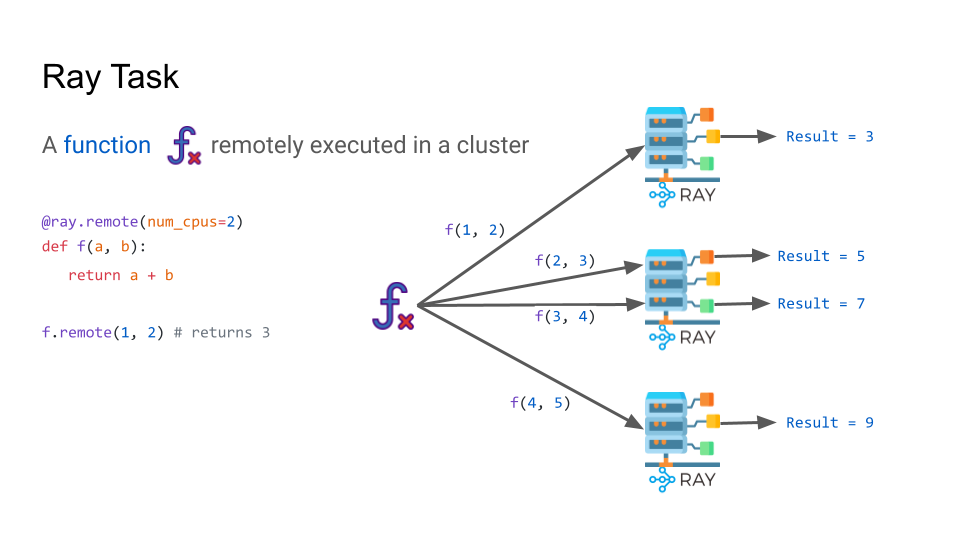

## Hands on em Ray AI

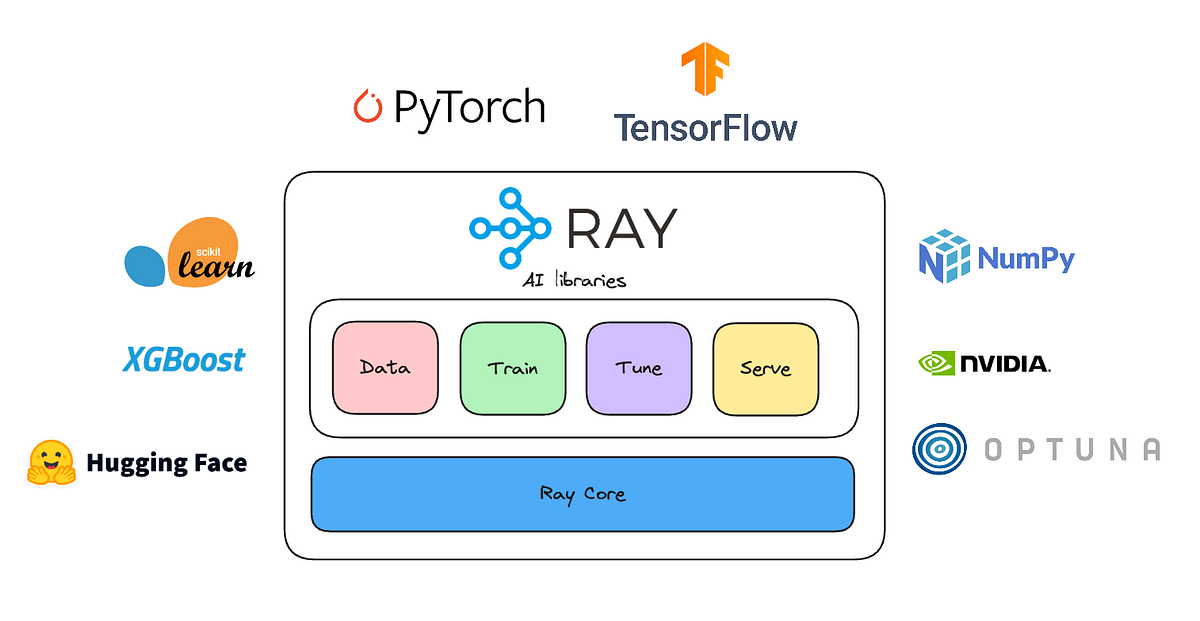

## Ray Tune: Paralelizando Otimização de Hiperparâmetros

A busca por hiperparâmetros é uma das fases mais complexas em termos computacionais, pois precisa de consecutivas execuções do modelo e avaliação de resultados.

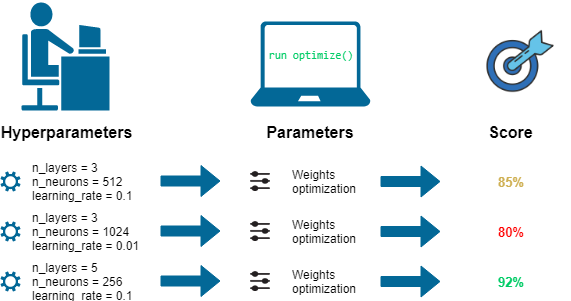

### Versão linear: um trial por execução

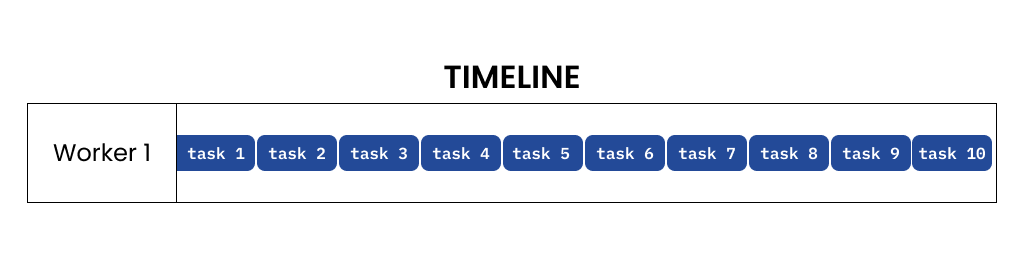

### Versão distribuída: os trials ocorrem em paralelo

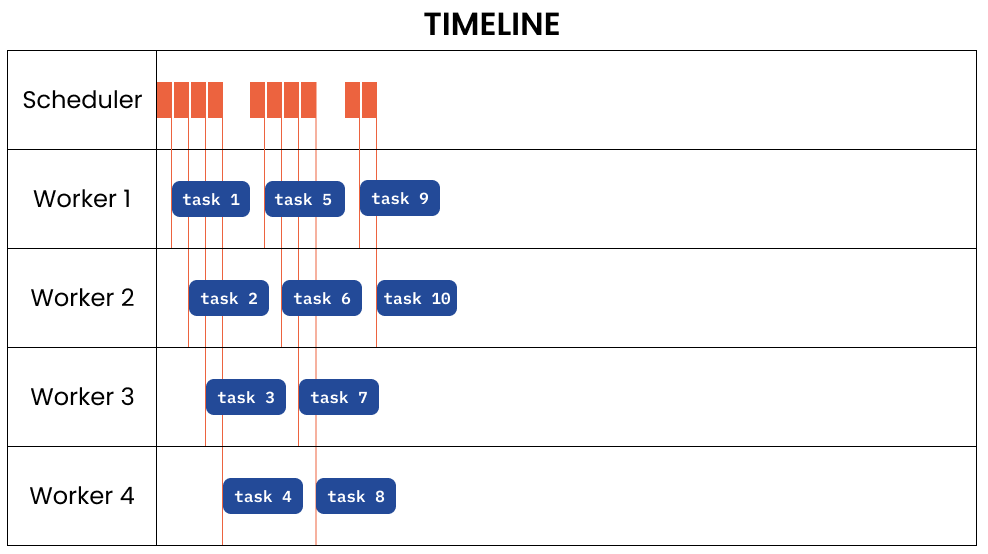

### Criando o Dataset

In [ ]:
from sklearn.datasets import make_classification
import pandas as pd

# Criar dataset grande
X, y = make_classification(
    n_samples=30_000,
    n_features=50,         # 50 colunas
    n_informative=30,      # 30 realmente relevantes
    n_redundant=10,        # 10 combinadas das informativas
    n_classes=2,
    random_state=42
)

# Converter X em DataFrame
X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])

# Converter y em Series
y = pd.Series(y, name="target")

X.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49
0,8.112636,0.053842,-2.991724,-1.104807,-2.387973,-4.263790,-1.712292,4.411400,-0.764134,2.329142,...,-0.253237,0.157301,4.433935,5.473192,-0.098117,2.193967,-0.198458,0.719888,0.060569,-10.980177
1,-2.083540,-1.797831,-4.367682,-0.015739,6.213829,-3.971882,-2.923069,-2.073483,-1.262587,-1.383874,...,0.312923,-2.976924,13.013676,-1.854690,-0.202275,2.757355,1.443974,6.604510,-25.609790,-5.765181
2,9.262566,1.051634,-3.616025,0.542965,-0.232103,-4.862591,0.200768,1.792420,0.687729,-2.542042,...,-1.087200,1.177025,-11.633871,0.737639,-5.212603,-1.995009,1.468144,1.214210,-6.439933,13.268496
3,4.347613,-1.491712,0.201796,-0.030860,2.878205,0.291675,-3.681276,2.664773,-1.316877,1.721789,...,-1.814182,0.685620,-3.145399,-1.107870,-1.406383,-2.627861,-1.253543,6.660084,-2.221790,-20.409066
4,2.825970,1.367205,0.257421,0.431396,-0.824280,3.158938,-3.154713,4.062587,-0.884677,1.074947,...,0.346285,4.017400,-4.263045,-0.768303,5.559343,2.526612,-1.338642,0.678974,-0.967622,-2.817217


In [ ]:
y.head()

,target
0,0
1,1
2,0
3,1
4,0


### Executando em GPU com Ray

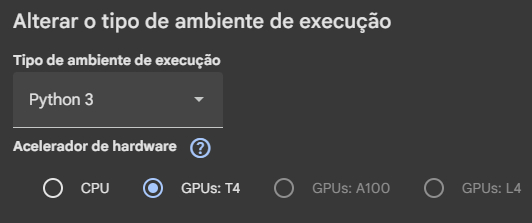

### Raytune: otimização paralelo de parâmetros

In [ ]:
!nvidia-smi

Thu Sep 25 19:39:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### a) Treinado o modelo em GPU + Ray Tune

In [ ]:
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler

import numpy as np
import pandas as pd

import cupy as cp
import cudf

from sklearn.datasets import make_classification
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.model_selection import train_test_split

# Inicializa Ray
ray.init(ignore_reinit_error=True)

# # Converter X em DataFrame
# X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])

# # Converter y em Series
# y = pd.Series(y, name="target")

# Move para GPU
X = cudf.DataFrame.from_pandas(X)
y = cudf.Series(y)

# Split treino/validação na GPU
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Função de treino
def train_rf(config):
    clf = cuRF(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        max_features=config["max_features"],
        bootstrap=config["bootstrap"],
        min_samples_leaf=config["min_samples_leaf"],
        criterion=config["criterion"]
    )

    clf.fit(X_train, y_train)
    score = clf.score(X_val, y_val)
    tune.report({"accuracy": float(score)})

# Espaço de busca
search_space = {
    "n_estimators": tune.choice([50, 100, 200, 300, 400]),
    "max_depth": tune.choice([5, 10, 20, 50, 100]),
    "min_samples_leaf": tune.choice([1, 2, 4, 8]),          # tamanho mínimo da folha
    "max_features": tune.choice(["sqrt", "log2"]),    # número de features consideradas por split
    "bootstrap": tune.choice([True, False]),               # amostragem com reposição
    "criterion": tune.choice(["gini", "entropy"]),         # função de divisão
}

# Scheduler ASHA para early stopping
scheduler = ASHAScheduler(
    grace_period=1,
    reduction_factor=2
)

# Rodando Ray Tune com melhor paralelismo
analysis = tune.run(
    train_rf,
    config=search_space,
    num_samples=3, # Alterar!
    resources_per_trial={"cpu": 2, "gpu": 1},
    scheduler=scheduler,
    metric="accuracy",
    mode="max",
    verbose=1
)

print("Melhor configuração:", analysis.best_config)
print("Melhor acurácia:", analysis.best_result["accuracy"])

2025-09-25 19:46:48,358	INFO worker.py:1789 -- Calling ray.init() again after it has already been called.
2025-09-25 19:46:50,815	INFO tensorboardx.py:193 -- pip install "ray[tune]" to see TensorBoard files.
2025-09-25 19:46:50,816	WARNING callback.py:143 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------+
| Configuration for experiment     train_rf_2025-09-25_19-46-50   |
+-----------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator          |
| Scheduler                        AsyncHyperBandScheduler        |
| Number of trials                 3                              |
+-----------------------------------------------------------------+

View detailed results here: /root/ray_results/train_rf_2025-09-25_19-46-50
(raylet) Warning: The actor ImplicitFunc is very large (24 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.

Trial status: 3 PENDING
Current time: 2025-09-25 19:46:51. Total running time: 0s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+---------------------------------------------------------------

2025-09-25 19:47:29,170	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_rf_2025-09-25_19-46-50' in 0.0053s.



Trial train_rf_613c3_00002 completed after 1 iterations at 2025-09-25 19:47:29. Total running time: 38s
+-----------------------------------------------+
| Trial train_rf_613c3_00002 result             |
+-----------------------------------------------+
| checkpoint_dir_name                           |
| time_this_iter_s                      0.70452 |
| time_total_s                          0.70452 |
| training_iteration                          1 |
| accuracy                              0.95167 |
+-----------------------------------------------+

Trial status: 3 TERMINATED
Current time: 2025-09-25 19:47:29. Total running time: 38s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: 613c3_00002 with accuracy=0.9516666531562805 and params={'n_estimators': 50, 'max_depth': 100, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}
+--------------------------------------------------------------------------

#### b) Exportando o modelo mais promissor

In [ ]:
import joblib

best_config = analysis.best_config

# Treina o modelo final com a melhor configuração
final_model = cuRF(
    n_estimators=best_config["n_estimators"],
    max_depth=best_config["max_depth"],
    max_features=best_config["max_features"],
    bootstrap=best_config["bootstrap"],
    min_samples_leaf=best_config["min_samples_leaf"],
    criterion=best_config["criterion"]
)

final_model.fit(X_train, y_train)

# Salva para servir
joblib.dump(final_model, "rf_best_model.pkl")


['rf_best_model.pkl']

## Ray Serve: Escalando a API de serving

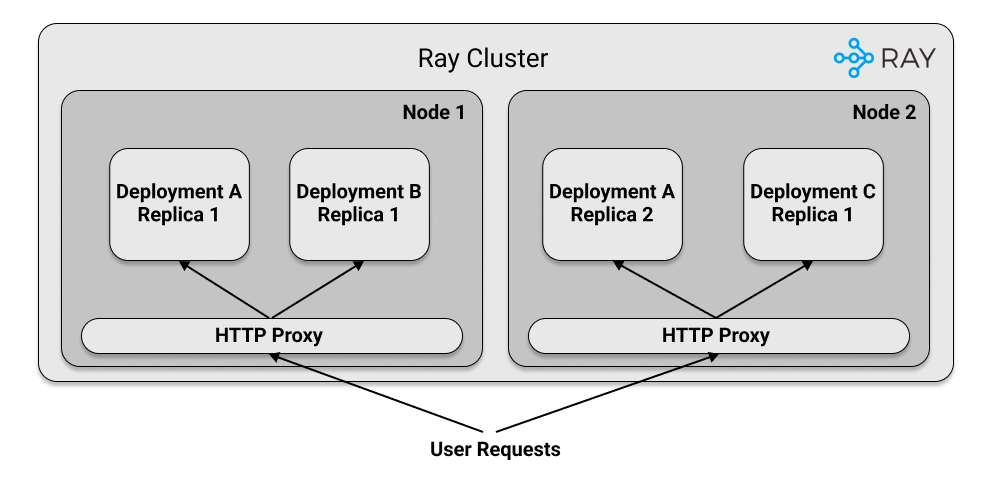

#### Subindo as réplicas

In [ ]:
from ray import serve
import cudf
import pandas as pd
import joblib

serve.shutdown()  # para reiniciar
serve.start(_internal_config={"log_level": "DEBUG"})  # inicia Ray Serve

@serve.deployment
class RFModel:
    def __init__(self):
        self.model = joblib.load("rf_best_model.pkl")  # carrega modelo
    async def __call__(self, request):
        # request espera JSON com features
        data = await request.json()
        print(data)
        df = pd.DataFrame(data)         # converte para DataFrame
        df_gpu = cudf.DataFrame.from_pandas(df)  # move para GPU
        preds = self.model.predict(df_gpu)
        print(data)
        return {"predictions": preds.to_arrow().to_pylist()}

# Bind e run com rota HTTP
RFModel_handle = RFModel.options(
    ray_actor_options={"num_cpus": 2, "num_gpus": 1}
).bind()

serve.run(RFModel_handle, route_prefix="/predict")


(ServeController pid=10160) INFO 2025-09-25 19:58:12,459 controller 10160 -- Removing 1 replica from Deployment(name='RFModel', app='default').
(ServeController pid=10160) INFO 2025-09-25 19:58:14,511 controller 10160 -- Replica(id='tnqmoz0s', deployment='RFModel', app='default') is stopped.
(ProxyActor pid=11202) INFO 2025-09-25 19:58:20,627 proxy 172.28.0.12 -- Proxy starting on node f1f0d74aa2dbbc2b85ef535a6ffac61644168d3b99d6975e9f33bbd6 (HTTP port: 8000).
INFO 2025-09-25 19:58:20,752 serve 249 -- Started Serve in namespace "serve".
INFO 2025-09-25 19:58:20,768 serve 249 -- Connecting to existing Serve app in namespace "serve". New http options will not be applied.
(ProxyActor pid=11202) INFO 2025-09-25 19:58:20,747 proxy 172.28.0.12 -- Got updated endpoints: {}.
(ServeController pid=11154) /usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:162: UserWarning: No NVIDIA GPU detected
(ServeController pid=11154)   warnings.warn("No NVIDIA GPU detected")
(ServeController pi

DeploymentHandle(deployment='RFModel')

#### Consumindo

In [ ]:
import requests

data = [
    {f"feature_{i}": 0.1 for i in range(50)},
    {f"feature_{i}": -0.9 for i in range(50)}
]

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=data
)

print(response.json())


(ServeReplica:default:RFModel pid=11263) [{'feature_0': 0.1, 'feature_1': 0.1, 'feature_2': 0.1, 'feature_3': 0.1, 'feature_4': 0.1, 'feature_5': 0.1, 'feature_6': 0.1, 'feature_7': 0.1, 'feature_8': 0.1, 'feature_9': 0.1, 'feature_10': 0.1, 'feature_11': 0.1, 'feature_12': 0.1, 'feature_13': 0.1, 'feature_14': 0.1, 'feature_15': 0.1, 'feature_16': 0.1, 'feature_17': 0.1, 'feature_18': 0.1, 'feature_19': 0.1, 'feature_20': 0.1, 'feature_21': 0.1, 'feature_22': 0.1, 'feature_23': 0.1, 'feature_24': 0.1, 'feature_25': 0.1, 'feature_26': 0.1, 'feature_27': 0.1, 'feature_28': 0.1, 'feature_29': 0.1, 'feature_30': 0.1, 'feature_31': 0.1, 'feature_32': 0.1, 'feature_33': 0.1, 'feature_34': 0.1, 'feature_35': 0.1, 'feature_36': 0.1, 'feature_37': 0.1, 'feature_38': 0.1, 'feature_39': 0.1, 'feature_40': 0.1, 'feature_41': 0.1, 'feature_42': 0.1, 'feature_43': 0.1, 'feature_44': 0.1, 'feature_45': 0.1, 'feature_46': 0.1, 'feature_47': 0.1, 'feature_48': 0.1, 'feature_49': 0.1}, {'feature_0': -0